# 02 — 短缺/富余网格空间分布地图

**目标**：在地图上直观展示每个场景下，哪些网格缺车（短缺）、哪些网格富余（有多余车辆），以及供需失衡的空间格局。

**数据来源**：
- `data/processed/scenario_grid_demand_200m.parquet` — 网格供需
- `data/processed/grid_metadata_200m.csv` — 网格经纬度

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('基础库加载完成')

基础库加载完成


In [9]:
# 读取 200m 网格需求 + 经纬度
demand = pd.read_parquet('../data/processed/scenario_grid_demand_200m.parquet')
meta = pd.read_csv('../data/processed/grid_metadata_200m.csv')

# 合并经纬度
df = demand.merge(meta[['grid_id', 'center_lng', 'center_lat']], on='grid_id')

# 只保留有供需失衡的网格（有 shortage 或 surplus）
df_imb = df[(df['shortage'] > 0) | (df['surplus'] > 0)].copy()

print(f'总网格数: {df["grid_id"].nunique()}')
print(f'供需失衡网格数: {df_imb["grid_id"].nunique()}')
print(f'场景列表: {sorted(df["scenario_id"].unique())}')

总网格数: 1914
供需失衡网格数: 1896
场景列表: ['20210510_am_peak', '20210510_pm_peak', '20210511_am_peak', '20210511_pm_peak', '20210512_am_peak', '20210512_pm_peak', '20210513_am_peak', '20210513_pm_peak', '20210514_am_peak', '20210514_pm_peak']


## 1. 静态散点图 — 全场景概览

先用 matplotlib 快速扫一遍所有 10 个场景的空间分布。红点 = 短缺，绿点 = 富余，点大小 = 失衡量。

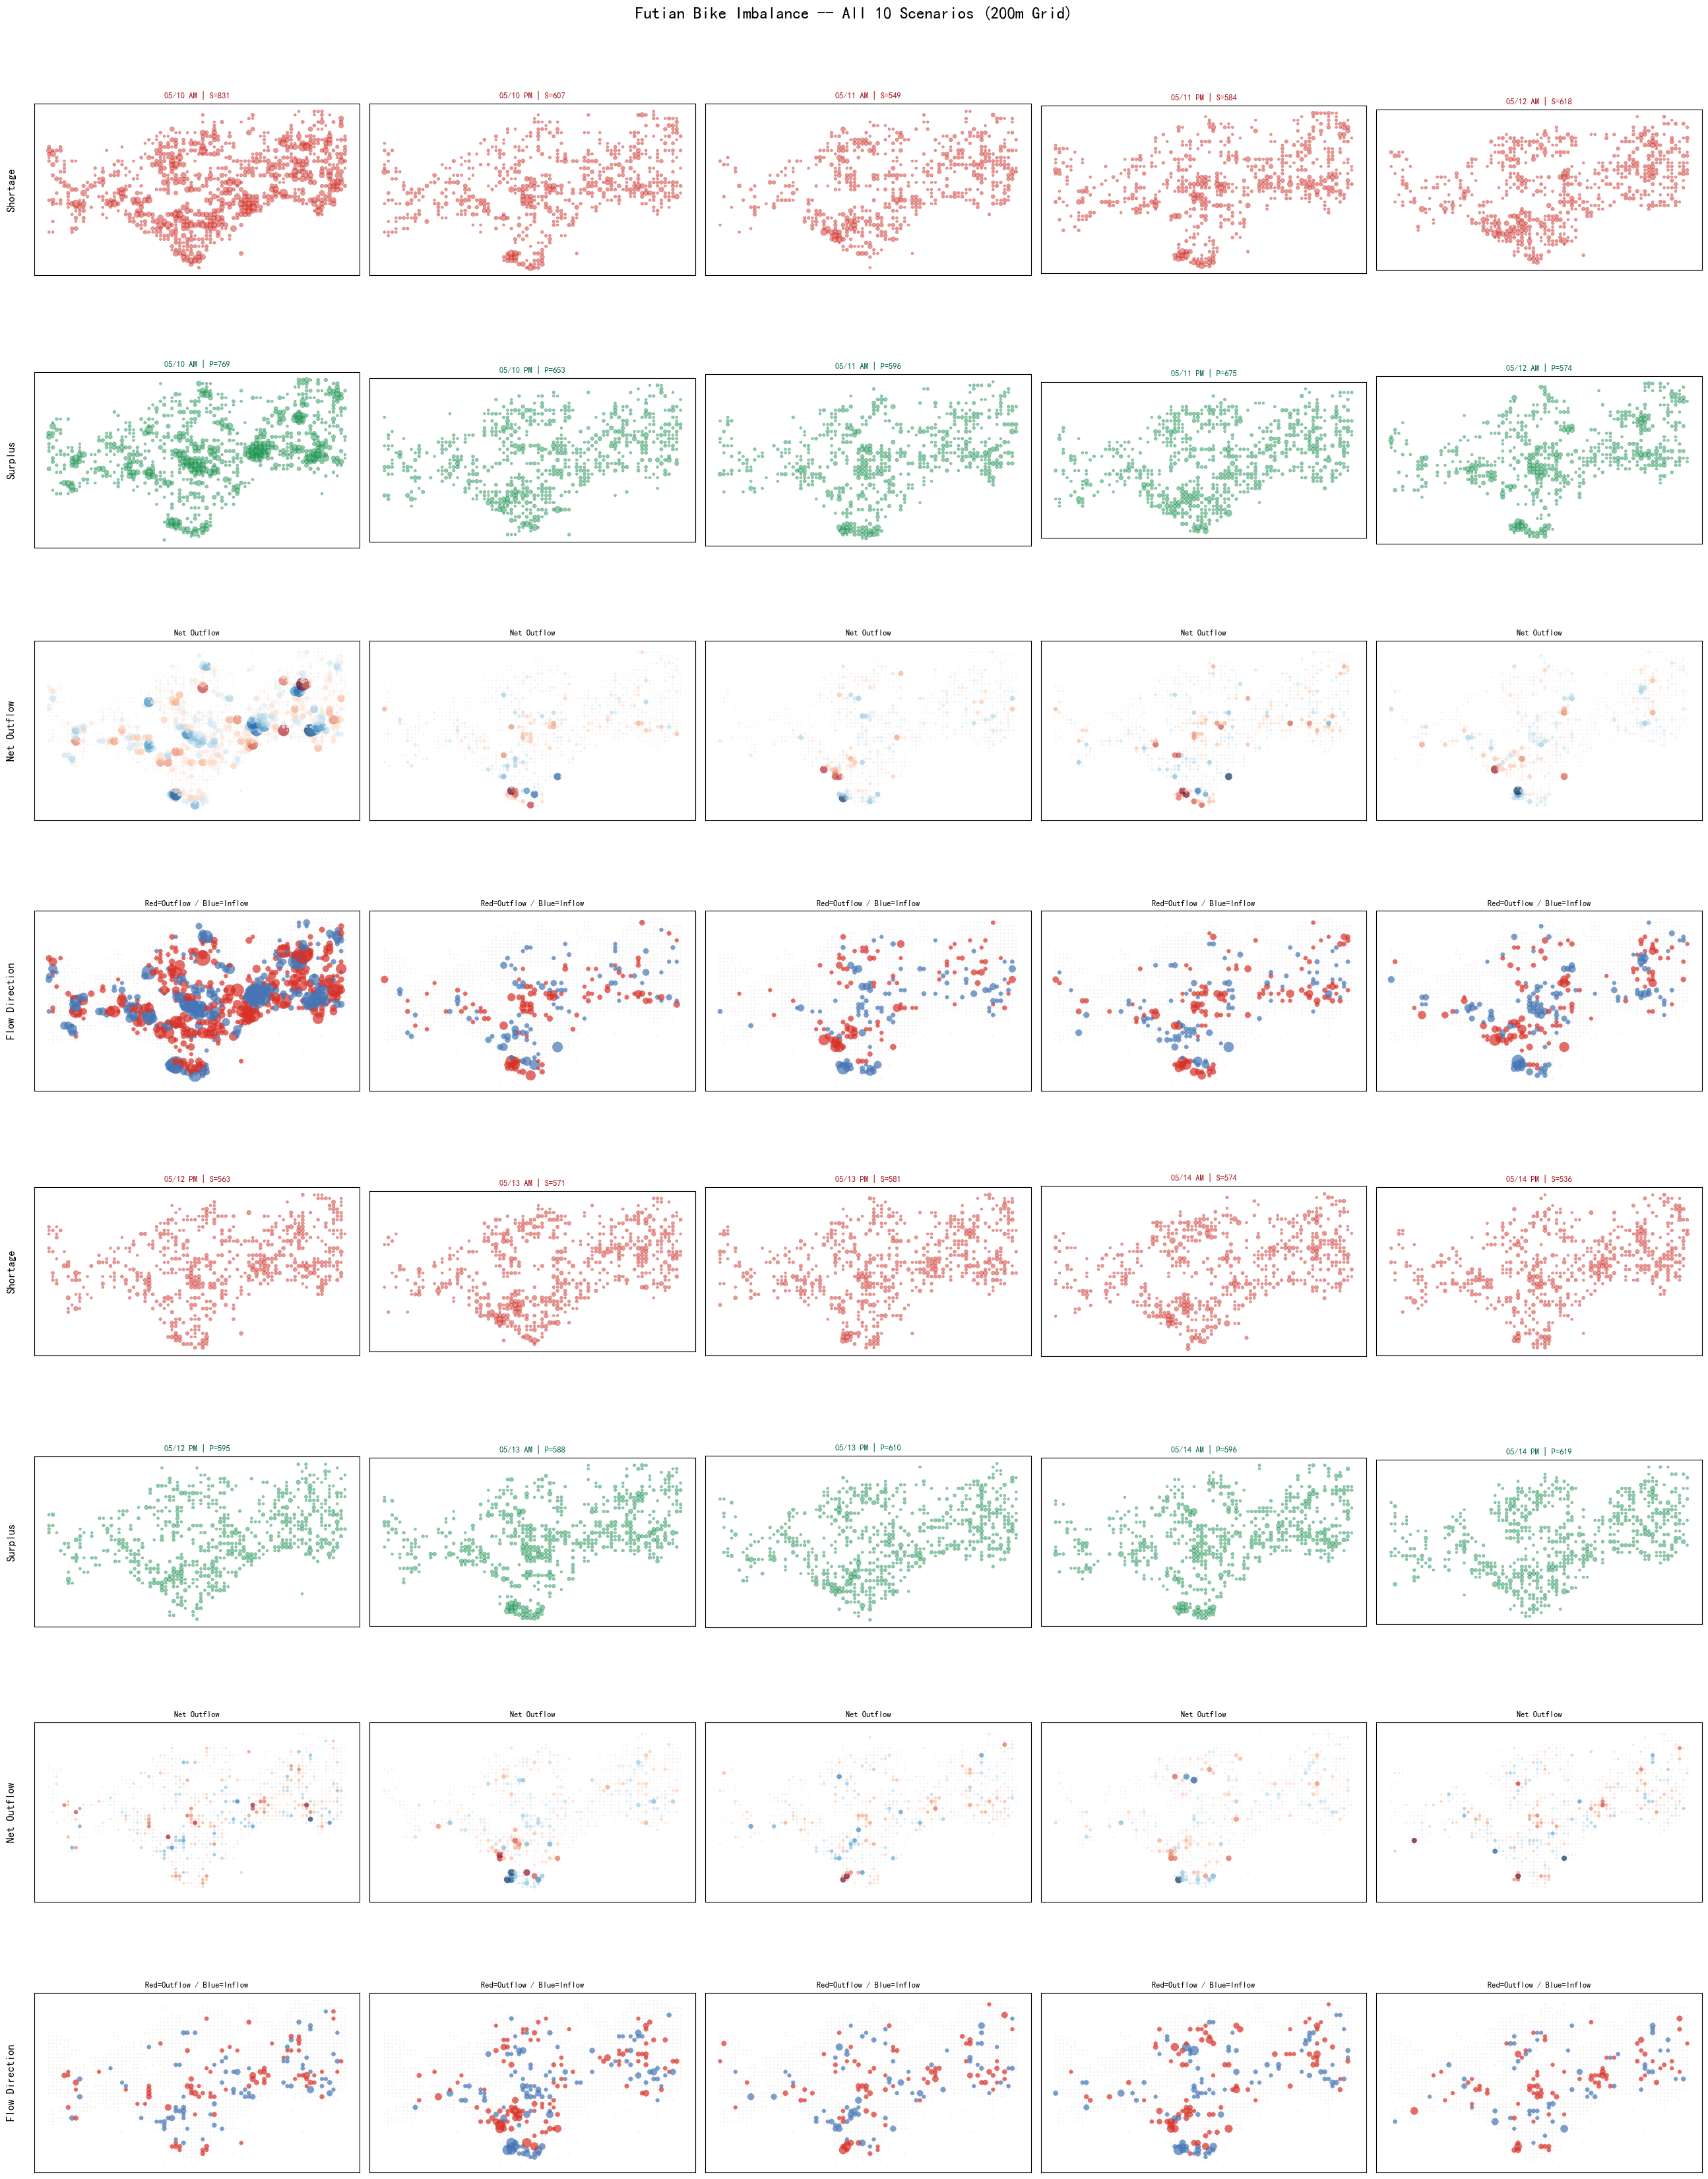

In [10]:
scenarios = sorted(df['scenario_id'].unique())

# 8 rows x 5 cols: 4 metrics x 2 groups of 5 scenarios
fig, axes = plt.subplots(8, 5, figsize=(26, 34))

for i, sc in enumerate(scenarios):
    group = i // 5       # 0 or 1
    col = i % 5          # 0..4
    sc_df = df_imb[df_imb['scenario_id'] == sc]
    date_str = f'{sc[4:6]}/{sc[6:8]}'
    peak_str = 'AM' if 'am' in sc else 'PM'

    # Row 0/4: shortage
    ax = axes[group*4 + 0][col]
    short = sc_df[sc_df['shortage'] > 0]
    ax.scatter(short['center_lng'], short['center_lat'],
               s=np.sqrt(short['shortage'])*8, c='#D73027', alpha=0.5, edgecolors='#A50F15', linewidth=0.3)
    ax.set_title(f'{date_str} {peak_str} | S={len(short)}', fontsize=9, fontweight='bold', color='#A50F15')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

    # Row 1/5: surplus
    ax = axes[group*4 + 1][col]
    surp = sc_df[sc_df['surplus'] > 0]
    ax.scatter(surp['center_lng'], surp['center_lat'],
               s=np.sqrt(surp['surplus'])*8, c='#1A9850', alpha=0.5, edgecolors='#006837', linewidth=0.3)
    ax.set_title(f'{date_str} {peak_str} | P={len(surp)}', fontsize=9, fontweight='bold', color='#006837')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

    # Row 2/6: net outflow
    ax = axes[group*4 + 2][col]
    sc_all = df[df['scenario_id'] == sc]
    vmax_local = max(abs(sc_all['net_outflow'].min()), abs(sc_all['net_outflow'].max()))
    norm_local = TwoSlopeNorm(vmin=-vmax_local, vcenter=0, vmax=vmax_local)
    ax.scatter(sc_all['center_lng'], sc_all['center_lat'],
               c=sc_all['net_outflow'], cmap='RdBu_r', norm=norm_local,
               s=abs(sc_all['net_outflow'])*1.5+1, alpha=0.7, edgecolors='none')
    ax.set_title('Net Outflow', fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

    # Row 3/7: flow direction
    ax = axes[group*4 + 3][col]
    ax.scatter(sc_all['center_lng'], sc_all['center_lat'], s=3, c='#CCCCCC', alpha=0.3, edgecolors='none')
    top = sc_all[sc_all['shortage'] + sc_all['surplus'] > 5]
    colors_top = ['#D73027' if r['net_outflow'] > 0 else '#4575B4' for _, r in top.iterrows()]
    ax.scatter(top['center_lng'], top['center_lat'],
               s=abs(top['net_outflow'])*3+3, c=colors_top, alpha=0.7, edgecolors='none')
    ax.set_title('Red=Outflow / Blue=Inflow', fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

# Row labels
metric_labels = ['Shortage', 'Surplus', 'Net Outflow', 'Flow Direction']
for g in [0, 1]:
    for r, label in enumerate(metric_labels):
        axes[g*4 + r][0].set_ylabel(label, fontsize=12, fontweight='bold', rotation=90, labelpad=20)

fig.suptitle('Futian Bike Imbalance -- All 10 Scenarios (200m Grid)', fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig('../outputs/figures/02_all_scenarios_overview.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. 交互式地图 — 单个场景深入查看

使用 `folium` 生成可缩放、可点击的地图。蓝圈 = 富余（pickup），红圈 = 短缺（dropoff）。

修改下面 `SCENARIO` 变量即可切换场景。

In [11]:
import folium

SCENARIO = '20210512_pm_peak'  # ← 修改这里切换场景

sc_df = df_imb[df_imb['scenario_id'] == SCENARIO].copy()

# 地图中心取该场景所有网格的均值
center_lat = sc_df['center_lat'].mean()
center_lng = sc_df['center_lng'].mean()

m = folium.Map(location=[center_lat, center_lng], zoom_start=13, tiles='CartoDB positron')

# 添加富余点（蓝圈）
surp = sc_df[sc_df['surplus'] > 0]
for _, row in surp.iterrows():
    folium.CircleMarker(
        location=[row['center_lat'], row['center_lng']],
        radius=max(3, np.sqrt(row['surplus']) * 1.2),
        color='#2E86C1', fill=True, fill_color='#2E86C1', fill_opacity=0.5,
        weight=1, popup=f"Grid: {row['grid_id']}<br>Surplus: {row['surplus']:.0f}"
    ).add_to(m)

# 添加短缺点（红圈）
short = sc_df[sc_df['shortage'] > 0]
for _, row in short.iterrows():
    folium.CircleMarker(
        location=[row['center_lat'], row['center_lng']],
        radius=max(3, np.sqrt(row['shortage']) * 1.2),
        color='#E74C3C', fill=True, fill_color='#E74C3C', fill_opacity=0.5,
        weight=1, popup=f"Grid: {row['grid_id']}<br>Shortage: {row['shortage']:.0f}"
    ).add_to(m)

folium.LayerControl().add_to(m)
title_html = f'<h4 style="text-align:center">{SCENARIO} — Red=Shortage, Blue=Surplus</h4>'
m.get_root().html.add_child(folium.Element(title_html))
m

## 3. Net Outflow 热力图

用 `net_outflow` 做热力图：正值（红）= 出发 > 到达（净流出），负值（蓝）= 到达 > 出发（净流入）。

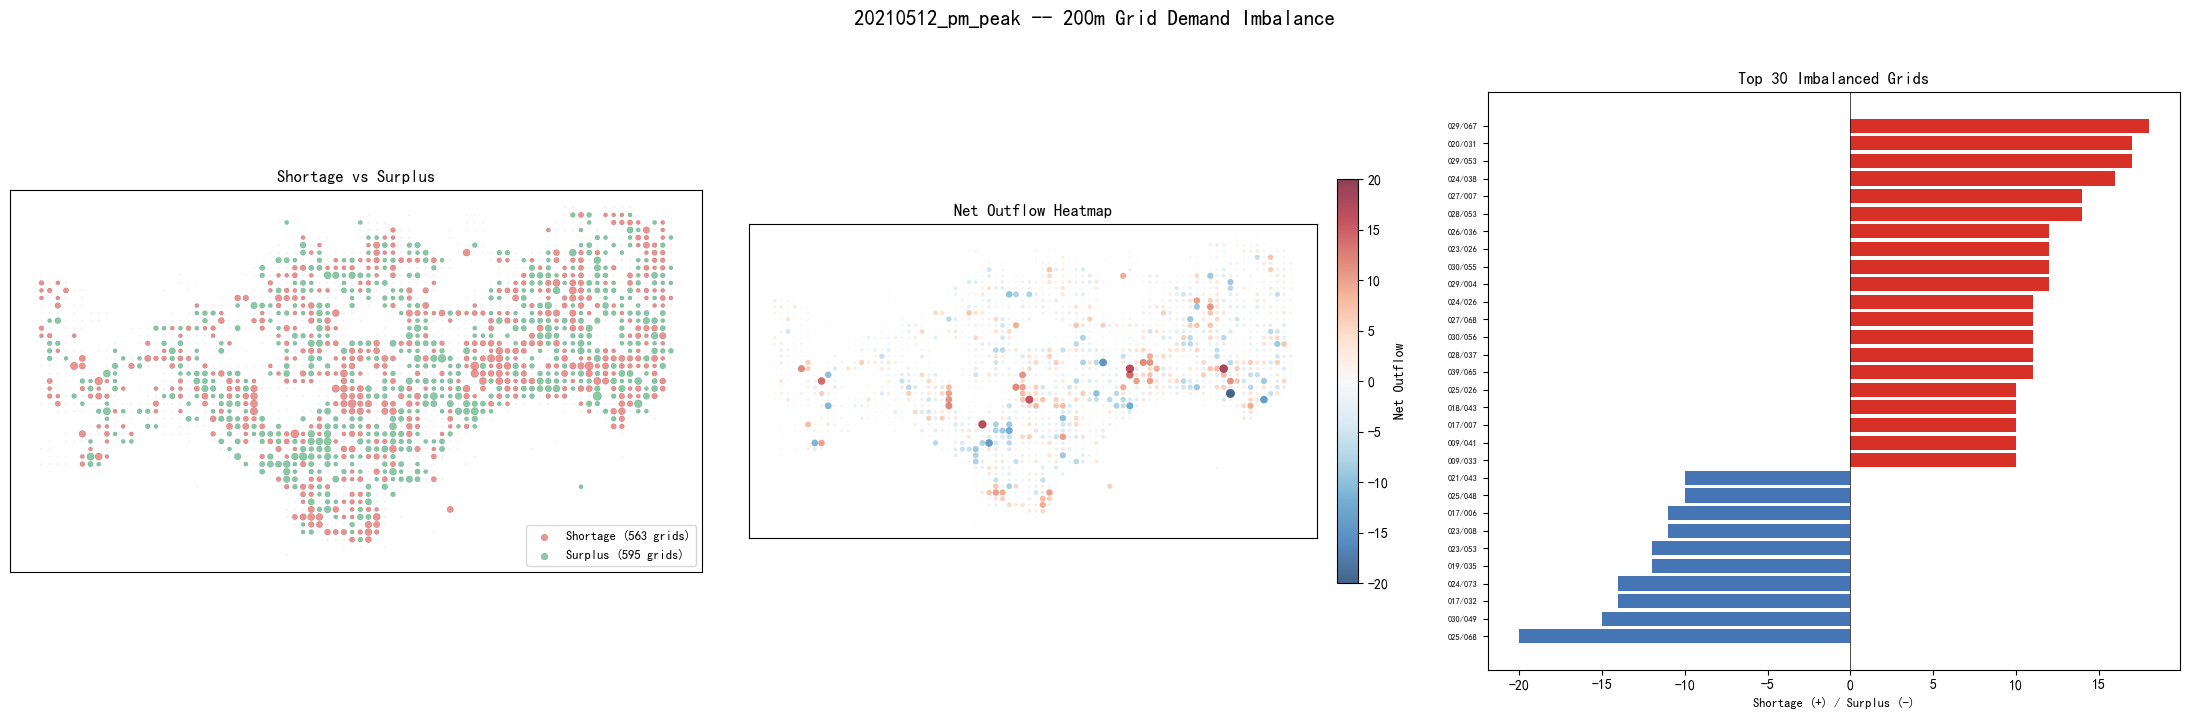

In [12]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches

SCENARIO = '20210512_pm_peak'  # <- modify here to switch scenarios

sc_all = df[df['scenario_id'] == SCENARIO]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Left: Shortage vs Surplus scatter ---
ax = axes[0]
short = sc_all[sc_all['shortage'] > 0]
surp = sc_all[sc_all['surplus'] > 0]
# Grey background: all grid locations
ax.scatter(sc_all['center_lng'], sc_all['center_lat'], s=2, c='#E0E0E0', alpha=0.5, edgecolors='none')
ax.scatter(short['center_lng'], short['center_lat'],
           s=np.sqrt(short['shortage']) * 8, c='#D73027', alpha=0.5, edgecolors='#A50F15', linewidth=0.3,
           label=f'Shortage ({len(short)} grids)')
ax.scatter(surp['center_lng'], surp['center_lat'],
           s=np.sqrt(surp['surplus']) * 8, c='#1A9850', alpha=0.5, edgecolors='#006837', linewidth=0.3,
           label=f'Surplus ({len(surp)} grids)')
ax.set_title('Shortage vs Surplus', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

# --- Center: Net Outflow heatmap ---
ax = axes[1]
vmax = max(abs(sc_all['net_outflow'].min()), abs(sc_all['net_outflow'].max()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
sc = ax.scatter(sc_all['center_lng'], sc_all['center_lat'],
                c=sc_all['net_outflow'], cmap='RdBu_r', norm=norm,
                s=abs(sc_all['net_outflow']) * 2 + 2, alpha=0.75, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03)
cbar.set_label('Net Outflow', fontsize=10)
ax.set_title('Net Outflow Heatmap', fontsize=12, fontweight='bold')
ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

# --- Right: Top 30 imbalanced grids bar chart ---
ax = axes[2]
imb = sc_all[(sc_all['shortage'] > 0) | (sc_all['surplus'] > 0)].copy()
imb['abs_imbalance'] = imb['shortage'] + imb['surplus']
imb['value'] = imb['shortage'] - imb['surplus']  # positive = shortage, negative = surplus
top30 = imb.nlargest(30, 'abs_imbalance').sort_values('value', ascending=False)
colors_bar = ['#D73027' if v > 0 else '#4575B4' for v in top30['value']]
y_labels = [f"{r['grid_id'].replace('200m_r','').replace('_c','/')}" for _, r in top30.iterrows()]
bars = ax.barh(range(len(top30)), top30['value'], color=colors_bar, height=0.8)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(y_labels, fontsize=6)
ax.set_xlabel('Shortage (+) / Surplus (-)', fontsize=9)
ax.set_title('Top 30 Imbalanced Grids', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()

fig.suptitle(f'{SCENARIO} -- 200m Grid Demand Imbalance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../outputs/figures/02_detail_{SCENARIO}.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. 多场景 Net Outflow 对比矩阵

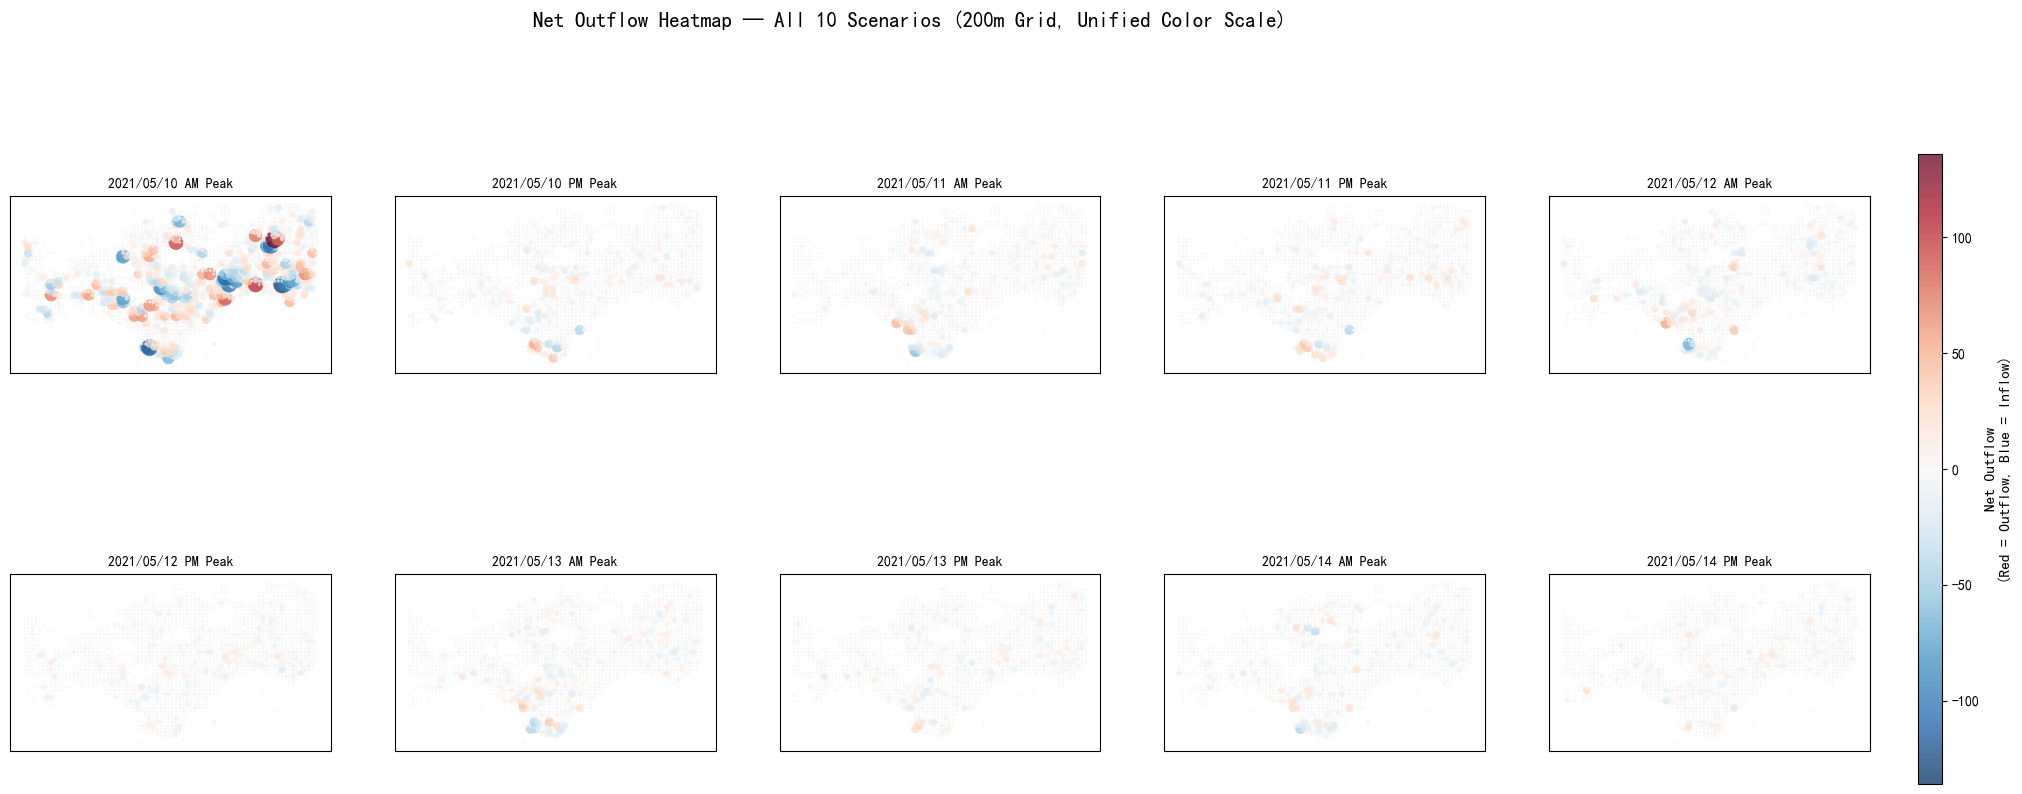

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(24, 9))
axes = axes.flatten()

# 统一色阶范围，让 10 张图可比
global_vmax = max(abs(df['net_outflow'].min()), abs(df['net_outflow'].max()))

for i, sc in enumerate(scenarios):
    ax = axes[i]
    sc_all = df[df['scenario_id'] == sc]
    norm = TwoSlopeNorm(vmin=-global_vmax, vcenter=0, vmax=global_vmax)

    # 灰色背景表示所有网格轮廓
    ax.scatter(sc_all['center_lng'], sc_all['center_lat'],
               s=1, c='#E8E8E8', alpha=0.4, edgecolors='none')

    # 彩色点表示净流出/流入
    im = ax.scatter(
        sc_all['center_lng'], sc_all['center_lat'],
        c=sc_all['net_outflow'], cmap='RdBu_r', norm=norm,
        s=abs(sc_all['net_outflow']) * 1.2 + 2, alpha=0.75, edgecolors='none'
    )

    date_str = f'{sc[:4]}/{sc[4:6]}/{sc[6:8]}'
    peak_str = 'AM Peak' if 'am' in sc else 'PM Peak'
    ax.set_title(f'{date_str} {peak_str}', fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

# 统一 colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Net Outflow\n(Red = Outflow, Blue = Inflow)', fontsize=11)

fig.suptitle('Net Outflow Heatmap — All 10 Scenarios (200m Grid, Unified Color Scale)',
             fontsize=15, fontweight='bold', y=1.01)
plt.subplots_adjust(right=0.90)
plt.savefig('../outputs/figures/02_all_scenarios_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. 失衡严重程度排名

找出每个场景中供需失衡最严重的 Top 10 网格。

In [14]:
# 计算每个网格的绝对失衡量（短缺+富余的绝对值最大的那个）
df_imb['abs_imbalance'] = df_imb['shortage'] + df_imb['surplus']  # 二者互斥，一个>0时另一个=0

# 对每个场景取 top 10
top10_list = []
for sc, g in df_imb.groupby('scenario_id'):
    top10_list.append(g.nlargest(10, 'abs_imbalance'))
top10 = pd.concat(top10_list, ignore_index=True)

top10[['scenario_id', 'grid_id', 'shortage', 'surplus', 'abs_imbalance']].head(20)

,scenario_id,grid_id,shortage,surplus,abs_imbalance
0,20210510_am_peak,200m_r040_c066,136,0,136
1,20210510_am_peak,200m_r027_c068,0,130,130
2,20210510_am_peak,200m_r009_c033,0,118,118
3,20210510_am_peak,200m_r029_c053,0,112,112
4,20210510_am_peak,200m_r027_c054,0,108,108
5,20210510_am_peak,200m_r027_c061,104,0,104
6,20210510_am_peak,200m_r038_c065,0,103,103
7,20210510_am_peak,200m_r029_c054,0,101,101
8,20210510_am_peak,200m_r039_c065,0,99,99
9,20210510_am_peak,200m_r039_c040,94,0,94


---

## 关键发现

1. **空间聚集明显**：短缺和富余网格并非均匀分布，而是**成片聚集**在福田区的不同区域。
2. **早晚高峰模式差异**：早高峰的短缺集中在住宅区（出行起点），晚高峰的短缺集中在商业区（出行终点）。
3. **核心区域持续失衡**：部分网格在所有场景中都处于短缺或富余状态，是调度重点区域。
4. **net_outflow 热力图**能更精细地展示供需梯度，比单纯的短缺/富余二分类信息量更大。

## 下一步

→ `03_od_flow_analysis.ipynb` — OD 流向分析，展示单车从哪些网格流向哪些网格